# Part 3: Echo program using interrupts

In this part, we will modify the echo program from Part 2 to use interrupts for handling UART input.

In [1]:
cp ../02_echo/link.ld .
cp ../02_echo/run.sh .

## 1. Intro

Our `virt` machine has multiple **exception levels**:

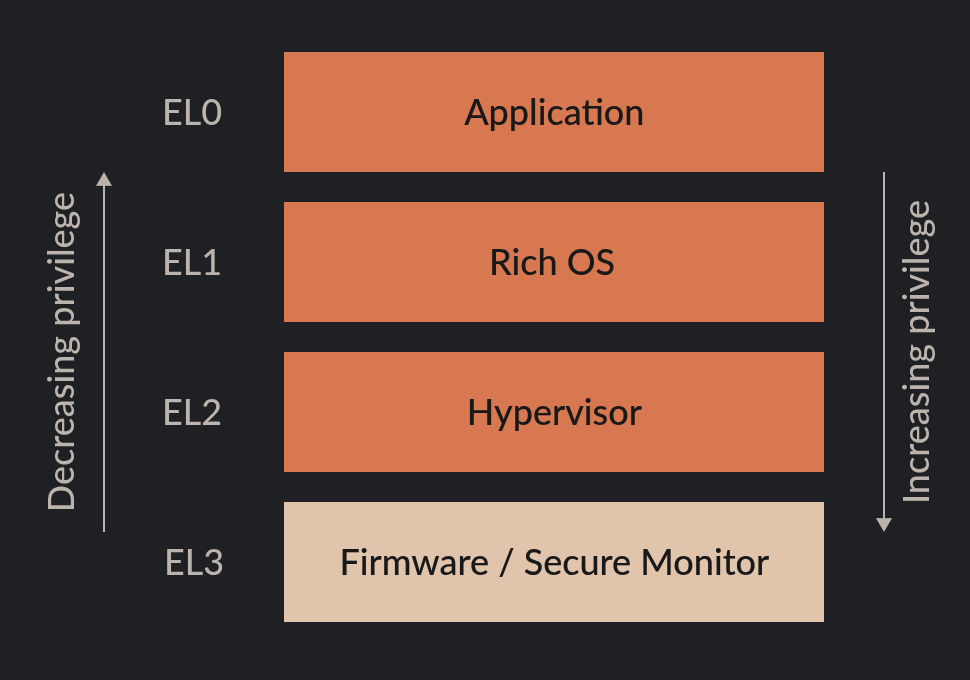

Each exception level has its own set of registers and can handle different types of exceptions. For our program, we will work exclusively with **EL1**.

The 

In [2]:
# Use the special `dumpdtb` machine option to write the device tree blob to a file
qemu-system-aarch64 -M virt -cpu max -nographic\
    -machine dumpdtb=/tmp/virt.dtb \
    -kernel /dev/null 2>&1 | tail -1

# Convert the dumped device tree blob to a human-readable format and extract the
# interrupt controller node (intc)
dtc -I dtb -O dts /tmp/virt.dtb 2>/dev/null | grep -A3 'intc@'

qemu-system-aarch64: info: dtb dumped to /tmp/virt.dtb. Exiting.
	intc@8000000 {
		phandle = <0x8002>;
		reg = <0x00 0x8000000 0x00 0x10000 0x00 0x8010000 0x00 0x10000>;
		compatible = "arm,cortex-a15-gic";


Here, the `reg` property of the `intc` node specifies four values:

- Base address of the Generic Interrupt Controller (GIC) distributor: 0x0800 0000
- Size of the GIC distributor region: 0x10000 (64 KB)
- Base address of the GIC CPU interface: 0x0801 0000
- Size of the GIC CPU interface region: 0x10000 (64 KB)

In [3]:
batcat --terminal-width 110 -r 23:24 -r 38:39 main.c

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: main.c
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
  23   │ /* Generic Interrupt Controller v2 distributor, confirmed at 0x08000000 via device tree dump */
  24   │ #define GICD_BASE 0x08000000UL
 ...   │ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ 8< ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─
  38   │ /* GICv2 CPU interface, confirmed at 0x08010000 via device tree dump */
  39   │ #define GICC_BASE 0x08010000UL
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


To handle interrupts in our program, we must also define a vector table. The vector table contains the addresses of the exception handlers for different types of exceptions, including interrupts. In our case, we are working exclusively in Exception Level 1 (EL1), so we set the `VBAR_EL1` register to the address of our vector table (defined in `vectors.S`, which we will get to shortly).

In [4]:
batcat --terminal-width 110 -r 15:19 start.S

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: start.S
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
  15   │     /* VBAR_EL1 is the register that holds the base address of the exception vector table for EL1.
  16   │     Load the address of the vectors table into x0 and write it to VBAR_EL1 */
  17   │     ldr x0, =vectors
  18   │     msr vbar_el1, x0
  19   │     isb
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


We also explicitly set the stack pointer to refer to `SP_EL1`, ensuring that our program uses the correct stack for Exception Level 1.  Specifically, setting the lowest bit of `SPSel` to 1 sets the
machine to use `SP_ELx` for Exception Level `x`, rather than all exception levels using the same stack pointer `SP_EL0`.

In [5]:
batcat --terminal-width 110 -r 1:14 start.S

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: start.S
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
   1   │ .section ".text.boot"
   2   │ .global _start
   3   │ 
   4   │ _start:
   5   │     /* Set sp to refer to the processor's stack pointer for EL1 (SP_EL1). */
   6   │     /* Does not set it, that is `mov sp, x0` below. */
   7   │     msr SPSel, #1
   8   │     /* Instruction Synchronization Barrier -- flush any previous instructions */
   9   │     isb
  10   │ 
  11   │     /* Load the address of the stack top into x0 and set sp to it */
  12   │     ldr x0, =stack_top
  13   │     mov sp, x0
  14   │ 
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


## 2. The Vector Table and Exception Handlers

`vector.S` sets up our vector table, which contains the addresses of the exception handlers for different types of exceptions, including interrupts. This table is crucial for the CPU to know where to jump when an exception occurs.

In [6]:
batcat --terminal-width 110 -r 86:109 vectors.S

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: vectors.S
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
  86   │ /** Write the exception vector table, aligned to 2^11 = 2048 bytes (0x800).
  87   │ Each entry is aligned to 2^7 bytes (0x80) due to the `ventry` macro. */
  88   │ .align 11
  89   │ .global vectors
  90   │ vectors:
  91   │     ventry  sync_el1t
  92   │     ventry  irq_el1t
  93   │     ventry  fiq_el1t
  94   │     ventry  error_el1t
  95   │ 
  96   │     ventry  sync_el1h
  97   │     ventry  irq_el1h
  98   │     ventry  fiq_el1h
  99   │     ventry  error_el1h
 100   │ 
 101   │     ventry  sync_el0_64
 102   │     ventry  irq_el0_64
 103   │     ventry  fiq_el0_64
 104   │     ventry  error_el0_64
 105   │ 
 106   │     ventry  sync_el0_32
 107   │     ventry  irq_el0_32
 108   │     ventry  fiq_el0_32
 109   │     ventry  

Here, `.align 11` matches the nature of the system register `VBAR_EL1`, which ignores the lower 11 bits of the address. This ensures that our vector table is properly aligned in memory, as required by the architecture.

Then, we use a `ventry` macro to define individual entries in the vector table:

In [7]:
batcat --terminal-width 110 -r 7:13 vectors.S

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: vectors.S
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
   7   │ /** Aligns to a 128-byte boundary (2^7 = 128 or 0x80), then writes a branch instruction to
   8   │ the given label. */
   9   │ .macro ventry label
  10   │     .align 7
  11   │     /* Branch to the given label */
  12   │     b   \label
  13   │ .endm
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


Since `vectors` is already aligned to a 128-byte boundary, the first `.align 7` does not skip any bytes, but each subsequent `.align 7` spaces the `b` (branch) instructions at the correct 128-byte intervals.

The labels are defined as follows:

In [8]:
batcat --terminal-width 110 -r 135:146 vectors.S

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: vectors.S
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
 135   │ sync_el1h:
 136   │     kernel_entry
 137   │     mov x0, #4
 138   │     bl  unexpected_exception
 139   │ irq_el1h:
 140   │     kernel_entry
 141   │     bl  irq_handler
 142   │     kernel_exit
 143   │ fiq_el1h:
 144   │     kernel_entry
 145   │     mov x0, #6
 146   │     bl  unexpected_exception
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


Similar code can be found for each type of exception (16 entries in total) in the vector table.
C convention is that `x0` is used to pass the first argument to a function, so we place the
index of the exception in the vector table into `x0`.

The `kernel_entry` and `kernel_exit` macros are named according to convention (we do not have
separate kernel and user space in this simple program), and they serve as the entry and exit points for handling exceptions. Their role is to save and restore the general-purpose registers and any other necessary state to ensure correct execution before and after the exception is handled:

In [9]:
batcat --terminal-width 110 -r 25:40 -r 53:68 -r 81:84 vectors.S

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: vectors.S
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
  25   │ /* Save all general-purpose registers x0-x29 using `stp`, which stores two registers at a
  26   │ time.  Then, load the exception return address (ELR_EL1) and saved program status register
  27   │ (SPSR_EL1) into x21 and x22, respectively. Store x30 and x21 (ELR_EL1) to the stack.
  28   │ Finally, store x22 (SPSR_EL1) to the stack using `str` (store a single register since there's
  29   │ only one left).
  30   │ 
  31   │ Total: 31 registers saved to the stack, plus 2 more for ELR_EL1 and SPSR_EL1, for a total of
  32   │ 33 * 8 = 264 bytes.  We round up to 272 bytes to maintain a 16-byte stack alignment.
  33   │ 
  34   │ Named `kernel_entry` by convention, even though we don't actually have kernel/userspace separation
  35   │

The final  `eret` instruction stands for `exception return`, which is used to return from an exception handler and resume execution at the point where the exception occurred. In our program,
this is only reached for the `IRQ` (Interrupt Request) exceptions, with all other exception handlers entering a `hang` block indefinitely (if they were somehow triggered; our setup does not enable them).

## 3. Setting up the Generic Interrupt Controller (GIC)

The Generic Interrupt Controller (GIC) is responsible for managing and prioritizing interrupts in the system. The relevant registers are as follows:

In [10]:
batcat --terminal-width 110 -r 23:50 main.c

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: main.c
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
  23   │ /* Generic Interrupt Controller v2 distributor, confirmed at 0x08000000 via device tree dump */
  24   │ #define GICD_BASE 0x08000000UL
  25   │ /* GICv2 distributor control register - master control for the entire distributor */
  26   │ #define GICD_CTLR          (*(volatile unsigned int *)(GICD_BASE + 0x000))
  27   │ /* GICv2 distributor (i)nterrupt (s)et-(enable) (r)egisters - each `int` sets 32 interrupts;
  28   │ e.g. to enable interrupt 33, use `GICD_ISENABLER(1) = (1 << 1);`. Writing 0 bits
  29   │ does not disable any interrupts. */
  30   │ #define GICD_ISENABLER(n)  (*(volatile unsigned int *)(GICD_BASE + 0x100 + 4 * (n)))
  31   │ /* GICv2 distributor interrupt priority registers - 1 byte (`char`) per interrupt from base,


Additionally, we must indentify the interrupt ID for our UART (PL011) device:

In [11]:
# Use the special `dumpdtb` machine option to write the device tree blob to a file
qemu-system-aarch64 -M virt -cpu max -nographic\
    -machine dumpdtb=/tmp/virt.dtb \
    -kernel /dev/null 2>&1 | tail -1

# Convert the dumped device tree blob to a human-readable format and extract the PL011 UART node
dtc -I dtb -O dts /tmp/virt.dtb 2>/dev/null | grep -A3 'pl011@'

qemu-system-aarch64: info: dtb dumped to /tmp/virt.dtb. Exiting.
	pl011@9000000 {
		clock-names = "uartclk\0apb_pclk";
		clocks = <0x8000 0x8000>;
		interrupts = <0x00 0x01 0x04>;
--
		stdout-path = "/pl011@9000000";
		rng-seed = <0xc5d82365 0xc270c07d 0xc09099f4 0xb6c21282 0x3aabe26c 0x3afe0284 0x2762de88 0x816cae27>;
		kaslr-seed = <0x810f92fe 0xe953f530>;
	};


From `interrupts = <0x00 0x01 0x04>;`, we see that the interrupt type is a SPI (Shared Peripheral Interrupt, `0x00`) with index `0x01`. Since the offset for SPI interrupts is 32, the interrupt ID for our UART device is `32 + 1 = 33`.

In [12]:
batcat --terminal-width 110 -r 20:21 main.c

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: main.c
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
  20   │ /* Confirmed via device tree dump: PL011 is wired to SPI 1 -> Interrupt ID 32+1 */
  21   │ #define UART0_IRQ 33
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


Given the above register addresses and interrupt ID for the UART device, we can configure the interrupt controller to handle UART interrupts appropriately:

In [13]:
batcat --terminal-width 110 -r 161:180 main.c

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: main.c
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
 161   │ static void gic_init(void)
 162   │ {
 163   │     /* Splits UART0_IRQ into the appropriate GICD_ISENABLER register and bit, then
 164   │     enable that bit. */
 165   │     GICD_ISENABLER(UART0_IRQ / 32) = 1u << (UART0_IRQ % 32);
 166   │ 
 167   │     /* Set the priority for the UART0_IRQ interrupt source - arbitrary since it's the only source
 168   │     we have. */
 169   │     GICD_IPRIORITYR(UART0_IRQ) = 0xa0;
 170   │ 
 171   │     /* Route the UART0_IRQ interrupt to CPU0 */
 172   │     GICD_ITARGETSR(UART0_IRQ) = 0x1;
 173   │ 
 174   │     /* Enable the GIC distributor */
 175   │     GICD_CTLR = 1;
 176   │     /* Allow through interrupts of any priority (0x00 to 0xff) */
 177   │     GICC_PMR = 0xff;
 178   │     /* Enable

Finally, we must instruct the UART device to generate interrupts for the GIC to handle, and write
to the appropriate bit in the `DAIFCLR` (Debug, Asynchronous, IRQ, FIQ Clear) register to enable IRQ (interrupt request) handling:

In [14]:
batcat --terminal-width 110 -r 182: main.c

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: main.c
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
 182   │ void main(void)
 183   │ {
 184   │     uart_puts(GREEN "Echo server. Type characters; they will be echoed back.\r\n" RESET);
 185   │ 
 186   │     gic_init();
 187   │     UART0_IMSC = UART0_RX;           /* enable receive interrupts */
 188   │ 
 189   │     /* DAIF clear, 0x2 bit (IRQ mask) 
 190   │        DAIF = Debug, Asynchronous abort, IRQ, FIQ masks
 191   │        Clearing the IRQ mask bit allows IRQ exceptions to be taken. */
 192   │     asm volatile("msr daifclr, #2");
 193   │ 
 194   │     for (;;)
 195   │         asm volatile("wfe");         /* sleep between interrupts */
 196   │ }
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


## 4. `irq_handler`

The `irq_handler` function in `main.c` is responsible for handling interrupts generated by devices such as the UART. It is invoked when an IRQ occurs and contains the logic to determine the source of the interrupt and respond appropriately.  In our case, we handle the interrupt silently if its
ID does not correspond to the UART device, whereas for the UART interrupt, we execute the necessary handling logic to process the interrupt appropriately.  (This works because our simple system does not care about any other interrupts, none of which should be enabled anyway.)

In [15]:
batcat --terminal-width 110 -r 134:159 main.c

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: main.c
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
 134   │ /* Called from vectors.S when a GIC-routed IRQ is taken at EL1 */
 135   │ void irq_handler(void)
 136   │ {
 137   │     /* Fetch the interrupt acknowledge register */
 138   │     unsigned int iar = GICC_IAR;
 139   │     /* Extract the interrupt ID (lowest 10 bits) */
 140   │     unsigned int irq = iar & 0x3ff;
 141   │ 
 142   │     /* If the interrupt is from UART0, handle it. Since we only set the "receive" bit in the
 143   │     interrupt mask (UART0_IMSC), any UART0 interrupt must be a receive interrupt: there is something
 144   │     in the receive buffer. */
 145   │     if (irq == UART0_IRQ) {
 146   │ 
 147   │         /* Read characters from the receive buffer until it is empty and echo them. */
 148   │         while (!(

See Section 3 above for the referenced GIC registers used in the `irq_handler`.

## 5. Full program

See the directory contents for the full program files. Running the program should give similar behavior to the `02_echo` program, but with interrupts for handling UART input rather than the polling method used previously.

Note that our `Makefile` has also changed to include `vectors.S` as a dependency and to compile it along with `start.S` and `main.c`.

In [16]:
./run.sh

aarch64-linux-gnu-gcc -march=armv8-a -mabi=lp64 -mgeneral-regs-only -mstrict-align -ffreestanding -fno-stack-protector -fno-pic -O2 -Wall -nostdlib -static -Wl,-T,link.ld -o start.elf start.S vectors.S main.c


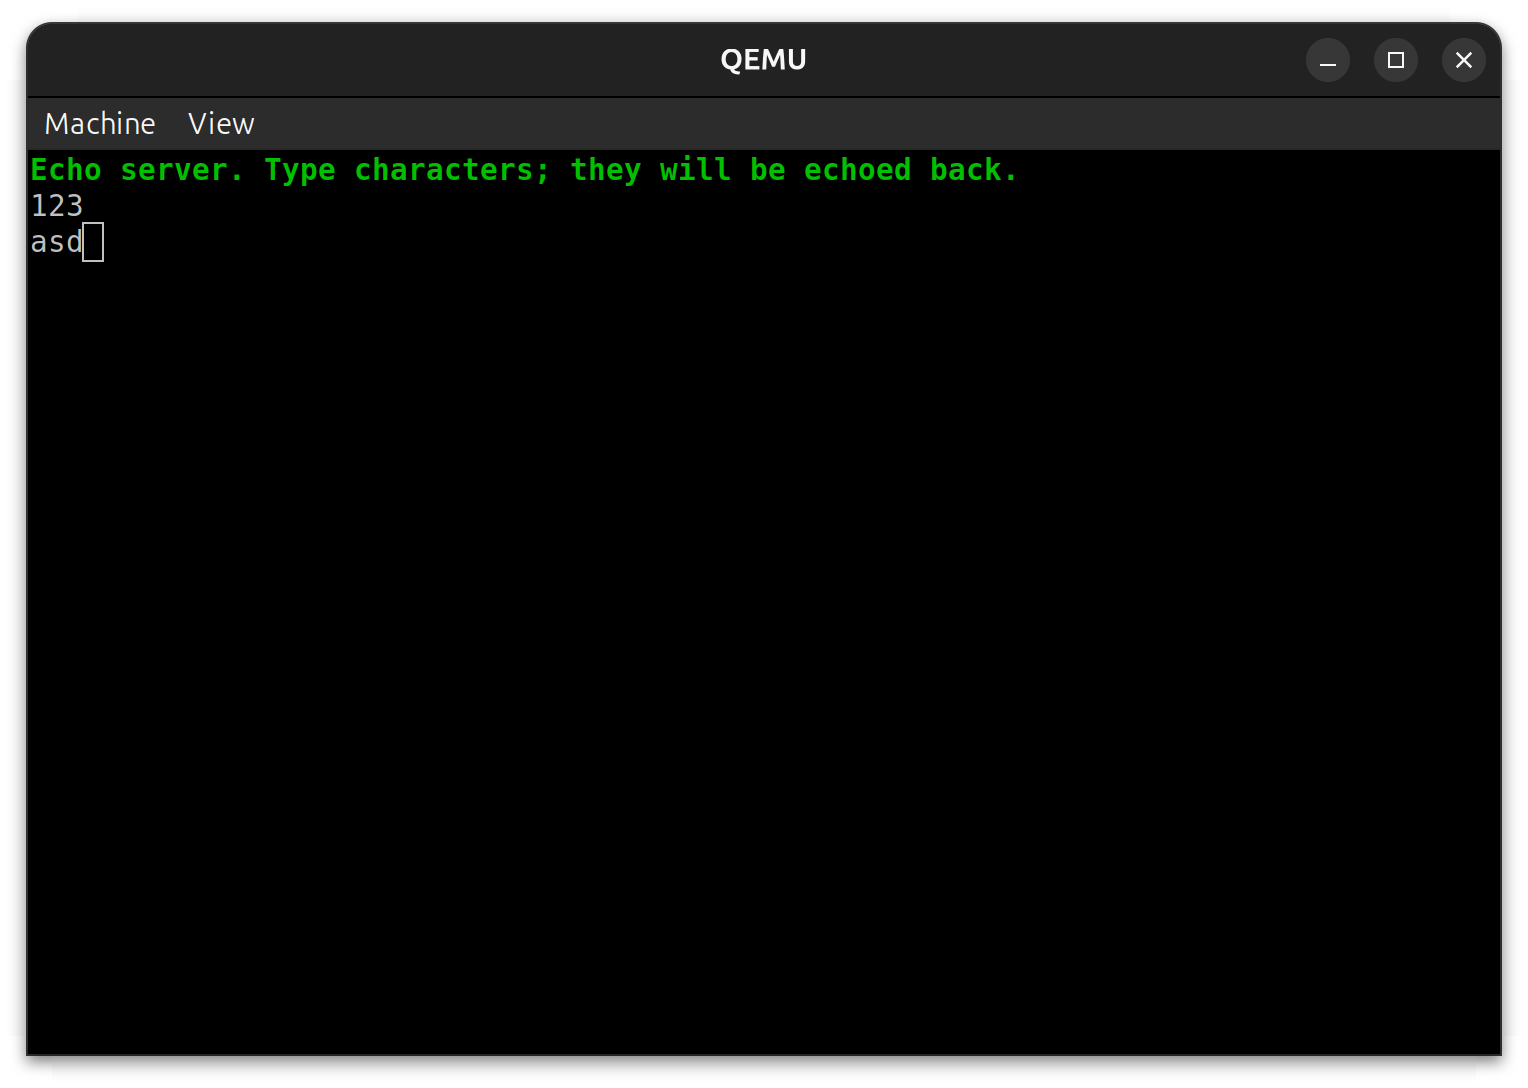